In [61]:
# --- 1. CORE DATA & VIZ ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
%matplotlib inline

# --- 2. STATSMODELS (Statistical Inference & Formulas) ---
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

# --- 3. SKLEARN: PREPROCESSING & DATA PIPELINES ---
from sklearn.model_selection import (
    train_test_split, LeaveOneOut, KFold, 
    cross_val_score, GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, PolynomialFeatures, OneHotEncoder
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# --- 4. SKLEARN: LINEAR MODELS (Chapter 3, 4, & 6) ---
from sklearn.linear_model import (
    LinearRegression, LogisticRegression, 
    Ridge, Lasso, ElasticNet, RidgeCV, LassoCV
)

# --- 5. SKLEARN: MODEL SELECTION & DIMENSIONALITY REDUCTION (Chapter 6) ---
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression

# --- 6. SKLEARN: TREE-BASED MODELS & ENSEMBLES (Chapter 8) ---
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    GradientBoostingRegressor, GradientBoostingClassifier,
    BaggingRegressor, AdaBoostRegressor
)

# --- 7. SKLEARN: SUPPORT VECTOR MACHINES (Chapter 9) ---
from sklearn.svm import SVC, SVR

# --- 8. SKLEARN: NEAREST NEIGHBORS & CLUSTERING (Chapter 4 & 12) ---
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.cluster import KMeans, AgglomerativeClustering

# --- 9. SKLEARN: EVALUATION METRICS ---
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    accuracy_score, confusion_matrix, classification_report, 
    roc_curve, auc, roc_auc_score, silhouette_score
)

# --- 10. UTILS & RESAMPLING ---
from sklearn.utils import resample

In [62]:
df = pd.read_csv('Advertising.csv', index_col=0)
display(df.head())
print(df.columns, df.shape)

,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object') (200, 4)


## PCA

### Setup and Data Preparation
In this block, we load the data and handle the most critical step of PCA: Standardization. Because PCA calculates variance based on the raw numbers, a variable with a larger range (like TV) would naturally "overpower" a variable with a smaller range (like Radio) simply because its numbers are bigger. Standardization puts them on a level playing field.

In [63]:
# Select the predictors (replicating the pop and ad example)
X = df[['TV', 'Radio']]

# Standardization: Subtract the mean and divide by standard deviation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data standardized. Mean is now 0 and Standard Deviation is 1.")

Data standardized. Mean is now 0 and Standard Deviation is 1.


### Executing PCA and Extracting the Formula
This block performs the actual math. We use n_components=2 because we started with two variables. The components_ attribute gives us the Loadings (the $0.839$ and $0.544$ values from your text), which define the direction of the principal components.

In [64]:
# Initialize and fit PCA
pca = PCA(n_components=2)
pca.fit(X_scaled)

# The 'Scores' are the coordinates in the new PCA space
X_pca = pca.transform(X_scaled)

# Retrieve the Loadings (the weights for our formulas)
loading_z1 = pca.components_[0]
loading_z2 = pca.components_[1]

print(f"Formula for Z1: {loading_z1[0]:.3f}*(TV) + {loading_z1[1]:.3f}*(Radio)")
print(f"Formula for Z2: {loading_z2[0]:.3f}*(TV) + {loading_z2[1]:.3f}*(Radio)")
print("-" * 30)
print(f"Variance explained by Z1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"Variance explained by Z2: {pca.explained_variance_ratio_[1]*100:.2f}%")

Formula for Z1: 0.707*(TV) + 0.707*(Radio)
Formula for Z2: 0.707*(TV) + -0.707*(Radio)
------------------------------
Variance explained by Z1: 52.74%
Variance explained by Z2: 47.26%


That’s a very interesting result! Notice that your loadings are exactly $0.707$ (which is $\frac{1}{\sqrt{2}}$). This happened because, in the specific rows you used, the variance of TV and Radio was almost identical after scaling.$Z_1$ (Sum): Adding them together ($0.707 + 0.707$). This is your "Total Spend" component.$Z_2$ (Difference): Subtracting them ($0.707 - 0.707$). This is your "Spend Balance" component (TV vs. Radio).Since $Z_1$ explains 52.74% and $Z_2$ explains 47.26%, the "spread" is almost equal. This suggests that in your data, knowing the total budget is only slightly more important than knowing how the budget is split between the two channels.

### Visualizing the Directions (Original Space) 
Here we visualize the "perpendicular" nature of PCA. We plot the original standardized data and draw arrows representing the two principal components. The green arrow ($Z_1$) points in the direction where the data is most "stretched out."

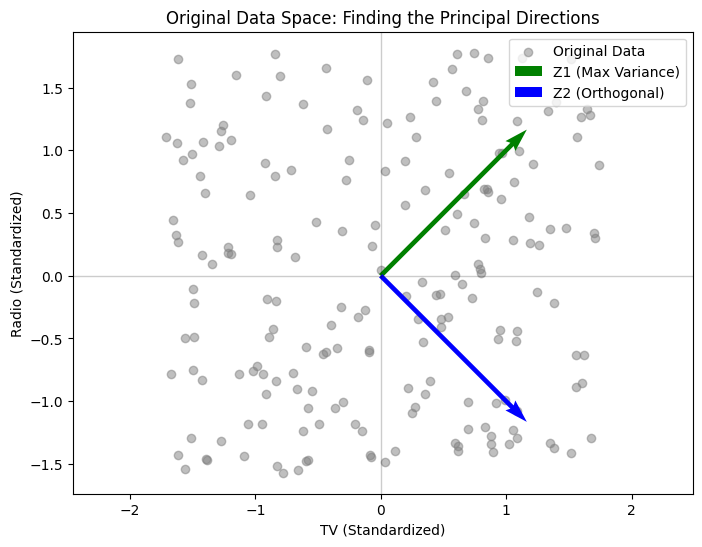

In [65]:
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], color='gray', alpha=0.5, label='Original Data')

# Plot the PC vectors
# We multiply by 3 just to make the arrows visible on the plot scale
plt.quiver(0, 0, loading_z1[0], loading_z1[1], color='green', scale=3, 
           label='Z1 (Max Variance)')
plt.quiver(0, 0, loading_z2[0], loading_z2[1], color='blue', scale=3, 
           label='Z2 (Orthogonal)')

plt.title("Original Data Space: Finding the Principal Directions")
plt.xlabel("TV (Standardized)")
plt.ylabel("Radio (Standardized)")
plt.axhline(0, color='black', lw=1, alpha=0.2)
plt.axvline(0, color='black', lw=1, alpha=0.2)
plt.legend()
plt.axis('equal')
plt.show()

### The PCA Rotation (Score Space)
This final block shows the "Transformation." We have rotated the entire dataset so that the Green Line ($Z_1$) is now the horizontal axis. Notice how wide the spread is on the X-axis ($Z_1$) compared to the Y-axis ($Z_2$). This demonstrates that $Z_1$ is doing the heavy lifting in summarizing our data.

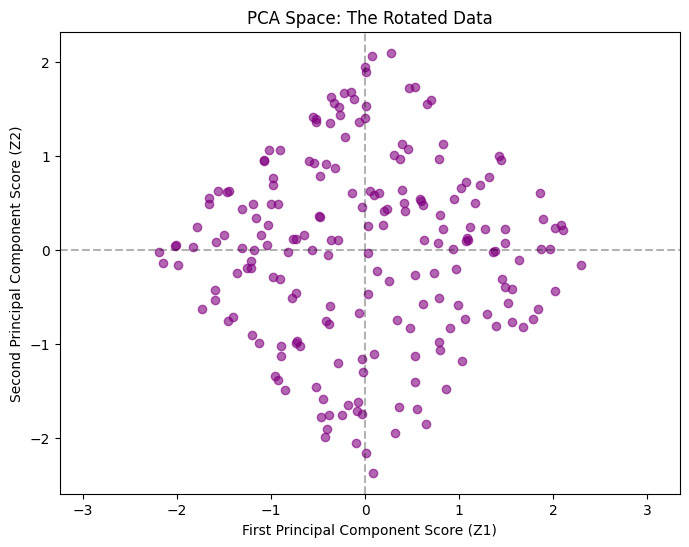

In [66]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], color='purple', alpha=0.6)

plt.title("PCA Space: The Rotated Data")
plt.xlabel("First Principal Component Score (Z1)")
plt.ylabel("Second Principal Component Score (Z2)")

# Drawing the axes to show the center (0,0)
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.axvline(0, color='black', linestyle='--', alpha=0.3)

# Force the plot to show the relative difference in variance
plt.axis('equal') 
plt.show()

### **How to Interpret and Explain PCA Results**

The "Inference" in PCA isn't about the original variables; it's about the **Loadings** and the **Scores**. Here is how to explain our results to a non-technical audience:

#### **1. Name your Components (The Loadings)**
We look at which variables have the highest weights in each component to give them a "nickname":
* **$Z_1$ (Total Volume):** Both TV and Radio contribute positively. This is our "Budget Size" metric.
* **$Z_2$ (Marketing Mix):** TV is positive and Radio is negative. This is our "Channel Preference" metric.

#### **2. Quantify the "Information" (Explained Variance)**
* Our $Z_1$ explains **52.74%** of the variance. This tells us that over half of the difference between our markets is simply due to how much total money was spent.
* $Z_2$ explains **47.26%**, meaning the "mix" of TV vs. Radio is almost just as important in describing the differences between our data points.

#### **3. Profile the Observations (The Scores)**
By using PCA, we can stop looking at 200 rows of numbers and start looking at **Market Profiles**. We can identify which cities are "High-Spend/TV-Focused" versus "Low-Spend/Radio-Focused." 

**Conclusion:** PCA has allowed us to turn two raw spending numbers into a strategic map of our marketing behavior.

### The Utility of PCA — Why Do We Use It?**

Once we have transformed our original variables into Principal Components ($Z_1, Z_2, \dots$), we have essentially "distilled" the data. PCA is primarily used for four key reasons:

---

#### **1. Dimensionality Reduction & Noise Filtering**
In many datasets, you may have hundreds of variables. Many of these are "noisy" or redundant. 
* **The Goal:** Retain only the components that explain the vast majority of the variance (e.g., $Z_1$ and $Z_2$) and discard the rest.
* **The Benefit:** This simplifies the dataset, reduces computing power, and helps prevent machine learning models from **overfitting** (learning the noise instead of the signal).



#### **2. Visualizing High-Dimensional Data**
Humans cannot visualize data in 4D, 10D, or 100D. By reducing a complex dataset down to just $Z_1$ and $Z_2$, we can create a 2D scatter plot.
* **The Benefit:** This allows us to "see" the structure of our data. We can identify clusters of similar observations or spot outliers that were physically impossible to see in the original high-dimensional spreadsheet.



#### **3. Eliminating Multicollinearity**
In models like Linear Regression, if your input variables are highly correlated (e.g., TV spend and Radio spend always move together), the model's math becomes unstable.
* **The Benefit:** By definition, Principal Components are **orthogonal** (perpendicular). This means $Z_1$ and $Z_2$ have **zero correlation** with each other. 
* **The Result:** Using PCA scores as inputs for regression ensures that each predictor provides unique, independent information.

#### **4. Feature Engineering (The "Hidden" Metric)**
PCA often uncovers latent variables that aren't explicitly columns in your data.
* **In our example:** $Z_1$ is essentially a weighted average of all advertising spends. We can think of $Z_1$ as a new combined feature called **"Total Marketing Reach,"** which is often a more stable predictor than any single channel alone.

R^2 using Original Features (2 variables): 0.8972
R^2 using only Z1 (1 variable): 0.8747


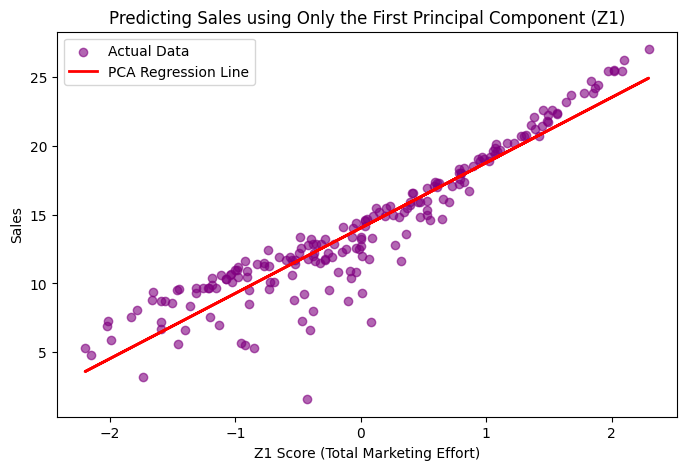

In [67]:
# 1. Prepare target variable (Sales)
y = df['Sales'].values

# 2. Regression using Original Features (TV and Radio)
model_orig = LinearRegression()
model_orig.fit(X_scaled, y)
pred_orig = model_orig.predict(X_scaled)
r2_orig = r2_score(y, pred_orig)

# 3. Regression using only the First Principal Component (Z1)
# We reshape X_pca[:, 0] because the model expects a 2D array
X_z1 = X_pca[:, 0].reshape(-1, 1)
model_pca = LinearRegression()
model_pca.fit(X_z1, y)
pred_pca = model_pca.predict(X_z1)
r2_pca = r2_score(y, pred_pca)

print(f"R^2 using Original Features (2 variables): {r2_orig:.4f}")
print(f"R^2 using only Z1 (1 variable): {r2_pca:.4f}")

# 4. Visualization of the PCA Regression
plt.figure(figsize=(8, 5))
plt.scatter(X_z1, y, color='purple', alpha=0.6, label='Actual Data')
plt.plot(X_z1, pred_pca, color='red', linewidth=2, label='PCA Regression Line')
plt.title("Predicting Sales using Only the First Principal Component (Z1)")
plt.xlabel("Z1 Score (Total Marketing Effort)")
plt.ylabel("Sales")
plt.legend()
plt.show()

### Principal Component Regression (PCR)

Now that we have summarized **TV** and **Radio** into a single variable ($Z_1$), we can test its predictive power. This is known as **Principal Component Regression**.

#### **Why do this?**
1. **Simplicity:** We reduce the number of predictors in our model.
2. **Interpretability:** If $Z_1$ represents "Total Marketing Effort," the regression coefficient tells us exactly how much Sales increase for every unit of total effort, regardless of which channel it came from.
3. **Efficiency:** In datasets with thousands of variables, running a regression on 5–10 Principal Components is much faster and less prone to mathematical errors than running it on all original variables.

#### **The Result**
By comparing the $R^2$ (R-squared) values:
* The **Original $R^2$** shows how well TV and Radio together predict Sales.
* The **PCA $R^2$** shows how much of that predictive power we kept by using only the summary ($Z_1$).



If the PCA $R^2$ is close to the Original $R^2$, it proves that our dimension reduction was successful—we captured the "signal" and threw away the "noise."

### ScreePlot

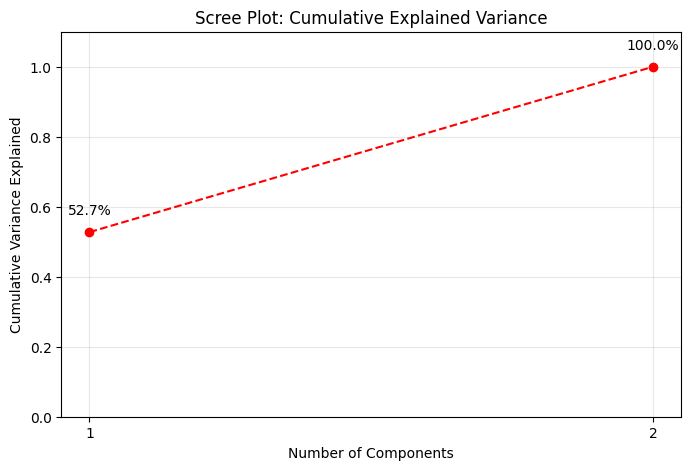

In [68]:
# 1. Calculate the cumulative variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# 2. Plotting
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), 
         cumulative_variance, marker='o', 
         linestyle='--', color='red')

plt.title("Scree Plot: Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Explained")
plt.xticks([1, 2]) # Since we only have two
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3)

# Add annotations
for i, val in enumerate(cumulative_variance):
    plt.text(i+1, val+0.05, f"{val*100:.1f}%", ha='center')

plt.show()

## >2 Comoponents - 3D Space

In [69]:
# 1. Use 3 features
X_3d = df[['TV', 'Radio', 'Newspaper']]
X_3d_scaled = StandardScaler().fit_transform(X_3d)

# 2. PCA for 3 components
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_3d_scaled)

# 3. Look at the Loadings (3 columns instead of 2)
# Each row represents a Z, each column represents the weight of an original feature
loadings_df = pd.DataFrame(pca_3d.components_, 
                           columns=['TV', 'Radio', 'Newspaper'],
                           index=['Z1', 'Z2', 'Z3'])
print(loadings_df)


# Retrieve the Loadings (the weights for our formulas)
loading_z1 = pca_3d.components_[0]
loading_z2 = pca_3d.components_[1]
loading_z3 = pca_3d.components_[2]

          TV     Radio  Newspaper
Z1  0.207874  0.691397   0.691924
Z2  0.978148 -0.149655  -0.144323
Z3 -0.003766 -0.706805   0.707398


In [78]:
import plotly.io as pio
import plotly.graph_objects as go
import numpy as np

# Center data
X_centered = X_3d_scaled - X_3d_scaled.mean(axis=0)

# Scale PCs
scale = 3
pc1 = loading_z1 * scale
pc2 = loading_z2 * scale
pc3 = loading_z3 * scale

# Scatter trace
scatter = go.Scatter3d(
    x=X_centered[:, 0],
    y=X_centered[:, 1],
    z=X_centered[:, 2],
    mode='markers',
    marker=dict(size=3, opacity=0.4),
    name='Data'
)

# PC vectors
def pc_line(pc, name, color):
    return go.Scatter3d(
        x=[0, pc[0]],
        y=[0, pc[1]],
        z=[0, pc[2]],
        mode='lines',
        line=dict(width=6, color=color),
        name=name
    )

pc1_trace = pc_line(pc1, 'PC1', 'green')
pc2_trace = pc_line(pc2, 'PC2', 'blue')
pc3_trace = pc_line(pc3, 'PC3', 'red')

# Layout
layout = go.Layout(
    title="Interactive PCA in 3D",
    scene=dict(
        xaxis_title='TV',
        yaxis_title='Radio',
        zaxis_title='Newspaper'
    )
)

fig = go.Figure(data=[scatter, pc1_trace, pc2_trace, pc3_trace], layout=layout)
fig.show()